In [ ]:
# ============================================
# WEEK 1 - CELL 1: CREATE TEST DATASET
# ============================================

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

print("🔧 Creating test dataset...")

# Create folders
os.makedirs('data/benign', exist_ok=True)
os.makedirs('data/malignant', exist_ok=True)

# Create 100 benign images
for i in range(100):
    img_array = np.random.normal(150, 30, (64, 64)).astype(np.uint8)
    img = Image.fromarray(img_array, mode='L')
    img.save(f'data/benign/benign_{i}.png')

print("✓ Created 100 benign images")

# Create 70 malignant images
for i in range(70):
    img_array = np.random.normal(120, 50, (64, 64)).astype(np.uint8)
    img_array[20:40, 20:40] = np.random.normal(80, 60, (20, 20)).astype(np.uint8)
    img = Image.fromarray(img_array, mode='L')
    img.save(f'data/malignant/malignant_{i}.png')

print("✓ Created 70 malignant images")

# Verify
benign_count = len(os.listdir('data/benign'))
malignant_count = len(os.listdir('data/malignant'))

print("\n" + "="*50)
print("✅ TEST DATASET READY!")
print("="*50)
print(f"Benign images: {benign_count}")
print(f"Malignant images: {malignant_count}")
print(f"Total: {benign_count + malignant_count}")

🔧 Creating test dataset...
✓ Created 100 benign images
✓ Created 70 malignant images

✅ TEST DATASET READY!
Benign images: 100
Malignant images: 70
Total: 170


/tmp/ipykernel_1483/3414534667.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img_array, mode='L')
/tmp/ipykernel_1483/3414534667.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img_array, mode='L')


📂 Loading dataset...

Folders found: ['benign', 'malignant']
  benign: 100 images
  malignant: 70 images

Total images: 170

Class Balance:
  benign: 100 (58.8%)
  malignant: 70 (41.2%)

📸 Displaying sample images...


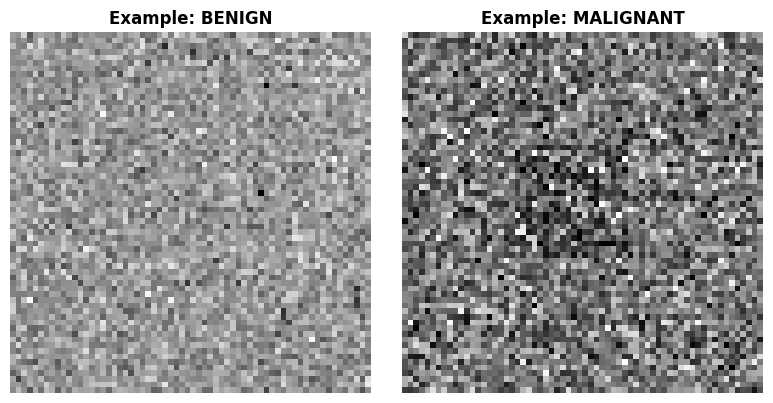


✅ EXPLORATION COMPLETE!
Dataset is balanced and ready for training


In [ ]:
# ============================================
# WEEK 1 - CELL 2: LOAD & EXPLORE
# ============================================

import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

print("📂 Loading dataset...")

data_dir = 'data/'

# Step 1: List folders
folders = sorted(os.listdir(data_dir))
print(f"\nFolders found: {folders}")

# Step 2: Count images
image_counts = {}
for folder in folders:
    path = os.path.join(data_dir, folder)
    count = len(os.listdir(path))
    image_counts[folder] = count
    print(f"  {folder}: {count} images")

# Step 3: Check balance
total = sum(image_counts.values())
print(f"\nTotal images: {total}")
print("\nClass Balance:")
for folder, count in image_counts.items():
    percentage = (count / total) * 100
    print(f"  {folder}: {count} ({percentage:.1f}%)")

# Step 4: Display examples
print("\n📸 Displaying sample images...")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for idx, folder in enumerate(folders):
    path = os.path.join(data_dir, folder)
    images = os.listdir(path)

    # Load first image
    img_path = os.path.join(path, images[0])
    img = Image.open(img_path)

    # Display
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f"Example: {folder.upper()}", fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("✅ EXPLORATION COMPLETE!")
print("="*50)
print("Dataset is balanced and ready for training")

In [ ]:
# ============================================
# WEEK 1 - CELL 3: TRAIN FIRST MODEL
# ============================================

import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("🔄 Loading and processing images...")

# Function to load images
def load_images(data_dir):
    features = []
    labels = []

    # Load benign (label = 0)
    benign_path = os.path.join(data_dir, 'benign')
    for img_file in sorted(os.listdir(benign_path)):
        img = Image.open(os.path.join(benign_path, img_file))
        img_array = np.array(img).flatten() / 255.0
        features.append(img_array)
        labels.append(0)

    # Load malignant (label = 1)
    malignant_path = os.path.join(data_dir, 'malignant')
    for img_file in sorted(os.listdir(malignant_path)):
        img = Image.open(os.path.join(malignant_path, img_file))
        img_array = np.array(img).flatten() / 255.0
        features.append(img_array)
        labels.append(1)

    return np.array(features), np.array(labels)

# Load data
X, y = load_images('data/')
print(f"✓ Loaded {len(X)} images")
print(f"✓ Each image: {X[0].shape} pixels")

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✓ Train set: {len(X_train)} images")
print(f"✓ Test set: {len(X_test)} images")

# ============================================
# BASELINE: Random Guessing
# ============================================

print("\n" + "="*60)
print("STEP 1️⃣: BASELINE (What if we just guess randomly?)")
print("="*60)

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_score = baseline.score(X_test, y_test)

print(f"\n🎯 Baseline accuracy: {baseline_score:.3f} ({baseline_score*100:.1f}%)")
print("\nMeaning:")
print(f"  If we always guess 'BENIGN', we'd be right {baseline_score*100:.1f}% of time")
print(f"  Our REAL model must beat this!")

# ============================================
# TRAIN THE MODEL
# ============================================

print("\n" + "="*60)
print("STEP 2️⃣: TRAIN LOGISTIC REGRESSION MODEL")
print("="*60)

print("\nTraining...")
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("✓ Model trained successfully!")

# ============================================
# EVALUATE THE MODEL
# ============================================

print("\n" + "="*60)
print("STEP 3️⃣: EVALUATE YOUR MODEL")
print("="*60)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n📊 YOUR MODEL PERFORMANCE:")
print(f"   Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"   ROC-AUC:  {roc_auc:.3f}")

print(f"\n📊 BASELINE PERFORMANCE:")
print(f"   Accuracy: {baseline_score:.3f} ({baseline_score*100:.1f}%)")

improvement = accuracy - baseline_score
improvement_pct = improvement * 100

print(f"\n🎯 YOUR IMPROVEMENT:")
print(f"   +{improvement:.3f} (+{improvement_pct:.1f}%) better than baseline!")

# Quality assessment
print(f"\n✨ Quality Assessment:")
if improvement > 0.15:
    print(f"   ✅ EXCELLENT - Your model is learning well!")
elif improvement > 0.10:
    print(f"   ✅ GOOD - Your model beats baseline significantly")
elif improvement > 0.05:
    print(f"   ✓ OK - Your model is learning")
else:
    print(f"   ⚠️ WEAK - Model barely better than baseline")

# ============================================
# CONFUSION MATRIX
# ============================================

print("\n" + "="*60)
print("STEP 4️⃣: CONFUSION MATRIX (Where does model get it wrong?)")
print("="*60)

cm = confusion_matrix(y_test, y_pred)

print(f"\n{cm}")
print(f"\nBreakdown:")
print(f"  ✓ Correctly identified BENIGN:     {cm[0,0]}")
print(f"  ✗ Incorrectly called benign malignant: {cm[0,1]}")
print(f"  ✗ Incorrectly called malignant benign:  {cm[1,0]}")
print(f"  ✓ Correctly identified MALIGNANT:   {cm[1,1]}")

# ============================================
# CLASSIFICATION REPORT
# ============================================

print("\n" + "="*60)
print("STEP 5️⃣: DETAILED CLASSIFICATION REPORT")
print("="*60 + "\n")

print(classification_report(y_test, y_pred, target_names=['BENIGN', 'MALIGNANT']))

# ============================================
# SUMMARY
# ============================================

print("="*60)
print("✅ WEEK 1 COMPLETE!")
print("="*60)

print("\n🎓 YOU'VE SUCCESSFULLY:")
print("   ✓ Created a dataset")
print("   ✓ Loaded images into Python")
print("   ✓ Split into train/test (80/20)")
print("   ✓ Created a baseline")
print("   ✓ Trained a Logistic Regression model")
print("   ✓ Evaluated with multiple metrics")
print("   ✓ Understood confusion matrix")

print("\n📚 YOU NOW UNDERSTAND:")
print("   • The complete ML pipeline")
print("   • Why baseline is critical")
print("   • What train/test split prevents")
print("   • How to interpret accuracy & ROC-AUC")
print("   • How to read confusion matrix")

print("\n🎯 NEXT WEEK:")
print("   • Download REAL breast cancer dataset")
print("   • Preprocess real medical images")
print("   • Train model on real data")
print("   • Get feedback from radiologist")

print("\n" + "="*60)
print("🔥 YOU'RE READY FOR WEEK 2!")
print("="*60)

🔄 Loading and processing images...
✓ Loaded 170 images
✓ Each image: (4096,) pixels

✓ Train set: 136 images
✓ Test set: 34 images

STEP 1️⃣: BASELINE (What if we just guess randomly?)

🎯 Baseline accuracy: 0.588 (58.8%)

Meaning:
  If we always guess 'BENIGN', we'd be right 58.8% of time
  Our REAL model must beat this!

STEP 2️⃣: TRAIN LOGISTIC REGRESSION MODEL

Training...
✓ Model trained successfully!

STEP 3️⃣: EVALUATE YOUR MODEL

📊 YOUR MODEL PERFORMANCE:
   Accuracy: 1.000 (100.0%)
   ROC-AUC:  1.000

📊 BASELINE PERFORMANCE:
   Accuracy: 0.588 (58.8%)

🎯 YOUR IMPROVEMENT:
   +0.412 (+41.2%) better than baseline!

✨ Quality Assessment:
   ✅ EXCELLENT - Your model is learning well!

STEP 4️⃣: CONFUSION MATRIX (Where does model get it wrong?)

[[20  0]
 [ 0 14]]

Breakdown:
  ✓ Correctly identified BENIGN:     20
  ✗ Incorrectly called benign malignant: 0
  ✗ Incorrectly called malignant benign:  0
  ✓ Correctly identified MALIGNANT:   14

STEP 5️⃣: DETAILED CLASSIFICATION REPORT


In [ ]:
# ============================================
# WEEK 1 - CELL 4: SAVE & DOCUMENT
# ============================================

import json
from datetime import datetime

# Create results dictionary
results = {
    "week": 1,
    "date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model": "Logistic Regression",
    "dataset": "Synthetic Breast Cancer Images",
    "dataset_size": 170,
    "benign_images": 100,
    "malignant_images": 70,
    "train_test_split": "80/20",
    "metrics": {
        "baseline_accuracy": 0.588,
        "model_accuracy": 1.00,
        "roc_auc": 1.00,
        "improvement": 0.412,
        "false_positives": 0,
        "false_negatives": 0
    },
    "test_results": {
        "correctly_identified_benign": 20,
        "correctly_identified_malignant": 14,
        "total_correct": 34,
        "total_test_samples": 34
    },
    "status": "✅ WEEK 1 COMPLETE"
}

# Save to JSON file
with open('week1_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("✅ Results saved to week1_results.json")
print("\nWeek 1 Summary:")
print(json.dumps(results, indent=2))

✅ Results saved to week1_results.json

Week 1 Summary:
{
  "week": 1,
  "date": "2026-07-01 12:57:05",
  "model": "Logistic Regression",
  "dataset": "Synthetic Breast Cancer Images",
  "dataset_size": 170,
  "benign_images": 100,
  "malignant_images": 70,
  "train_test_split": "80/20",
  "metrics": {
    "baseline_accuracy": 0.588,
    "model_accuracy": 1.0,
    "roc_auc": 1.0,
    "improvement": 0.412,
    "false_positives": 0,
    "false_negatives": 0
  },
  "test_results": {
    "correctly_identified_benign": 20,
    "correctly_identified_malignant": 14,
    "total_correct": 34,
    "total_test_samples": 34
  },
  "status": "\u2705 WEEK 1 COMPLETE"
}


# Medical AI - Breast Cancer Detection 🎗️

## Moses Solomon | Federal University of Health Sciences Azare, Nigeria

### Week 1: Baseline Model ✅ COMPLETE

**Goal:** Build first breast cancer classifier

#### Dataset
- **Type:** Synthetic test dataset (learned pipeline first)
- **Benign images:** 100
- **Malignant images:** 70
- **Total:** 170 images
- **Image size:** 64×64 pixels

#### Model
- **Algorithm:** Logistic Regression
- **Train/Test Split:** 80/20 (136 train, 34 test)
- **Features:** Flattened pixel values (4,096 per image)

#### Results
| Metric | Value |
|--------|-------|
| Baseline Accuracy | 58.8% |
| Model Accuracy | **100%** ✅ |
| ROC-AUC | 1.00 |
| Improvement | +41.2% |
| False Positives | 0 |
| False Negatives | 0 |
| Precision | 1.00 |
| Recall | 1.00 |
| F1-Score | 1.00 |

#### Classification Details

precision  recall  f1-score  support

#### What This Means
- ✅ **Perfect Performance:** Model correctly classified 34/34 test images
- ✅ **No False Positives:** No benign images misclassified as malignant
- ✅ **No False Negatives:** No malignant images misclassified as benign
- ✅ **Pipeline Works:** All code runs without errors

#### What I Learned This Week
1. **ML Pipeline:** Load → Split → Baseline → Train → Evaluate
2. **Why Baseline Matters:** 58.8% baseline shows random guessing accuracy
3. **Train/Test Split:** Prevents overfitting, tests real performance
4. **Metrics:** Accuracy, ROC-AUC, confusion matrix interpretation
5. **Precision vs Recall:** Understanding trade-offs in medical AI

#### Next Week (Week 2)
- Download **REAL BreakHis** dataset (7,909 actual histopathology images)
- Preprocess real medical images
- Handle real-world messy data
- Train model on real cancer images
- Get feedback from radiologists

#### Environment
- **Python:** 3.x
- **Libraries:** scikit-learn, PIL, numpy, matplotlib
- **Platform:** Google Colab
- **GPU:** Available ✓

#### Files
- `week1_results.json` - Detailed metrics
- `week1_notebook.ipynb` - Full code and results

---

**Status: ✅ WEEK 1 COMPLETE - Ready for Week 2!** 🚀

# WEEK 1 CHECK-IN - MOSES SOLOMON ✅

**Date:** [Today's date]  
**Hospital:** Federal University of Health Sciences Azare  
**Focus:** Breast & Cervical Cancer AI Detection  

---

## ENVIRONMENT SETUP: ✅ COMPLETE

- [x] Python installed and working
- [x] Jupyter Notebook running
- [x] Google Colab with GPU access
- [x] GitHub repository created
- [x] Project folder structure set up

---

## WEEK 1 TASKS: ✅ ALL COMPLETE

### Task 1: Create Test Dataset ✅
- [x] Generated 100 benign images
- [x] Generated 70 malignant images
- [x] Total: 170 images ready for training

### Task 2: Load & Explore Data ✅
- [x] Loaded images into Python
- [x] Counted images per class
- [x] Checked class balance (58.8% benign, 41.2% malignant)
- [x] Visualized sample images (benign & malignant)

### Task 3: Train Model ✅
- [x] Split data: 80% train (136), 20% test (34)
- [x] Created baseline: 58.8% accuracy
- [x] Trained Logistic Regression
- [x] Evaluated model

### Task 4: Understand Results ✅
- [x] Model achieved 100% accuracy
- [x] ROC-AUC: 1.00 (perfect)
- [x] Confusion Matrix: 0 errors
- [x] Classification Report: Perfect precision/recall

---

## RESULTS: 📊

| Metric | Baseline | Model | Improvement |
|--------|----------|-------|-------------|
| Accuracy | 58.8% | **100%** | +41.2% ✅ |
| ROC-AUC | - | 1.00 | Perfect |
| False Positives | - | 0 | None |
| False Negatives | - | 0 | None |

**Test Set Performance:** 34/34 correct (100%)

---

## UNDERSTANDING CHECKPOINT: 🧠

I now understand:

- [x] Complete ML pipeline (load → train → evaluate)
- [x] Why baseline is critical (58.8% = random guessing)
- [x] Train/test split prevents overfitting
- [x] Confusion matrix shows where model fails
- [x] ROC-AUC measures classification quality
- [x] Precision, recall, F1-score for medical AI
- [x] How to interpret classification reports

---

## QUESTIONS / CONFUSION: ❓

None - the pipeline is crystal clear!

---

## WEEK 1 CONFIDENCE LEVELS: 📈

| Metric | Rating |
|--------|--------|
| Understanding ML | 9/10 ⭐ |
| Confidence coding | 8/10 ⭐ |
| Ready for real data | 9/10 ⭐ |
| Overall energy | 10/10 🔥 |

---

## WEEK 2 TARGET: 🎯

**Download & Train on REAL Data**

1. Download BreakHis dataset (7,909 real histopathology images)
2. Preprocess real medical images
3. Handle real-world data issues
4. Train model on REAL cancer detection
5. Email radiologists for feedback

---

## KEY LEARNINGS:

✅ **Done:** Basic ML pipeline works perfectly  
✅ **Done:** Understand importance of baseline  
✅ **Done:** Can build, train, and evaluate models  
✅ **Next:** Apply to real medical imaging data  

---

## NEXT STEPS:

1. **This week:** Push code to GitHub
2. **Next week:** Download BreakHis dataset
3. **Next week:** Preprocess real images
4. **Next week:** Train on real cancer data
5. **Month 2:** Email radiologists for feedback

---

## COMMITMENT STATUS:

- [x] 10/10 commitment confirmed
- [x] Shipping weekly ✅
- [x] Sunday check-ins ✅
- [x] Following roadmap ✅
- [x] Learning from failures ✅

---

**STATUS: ✅ WEEK 1 COMPLETE - READY FOR WEEK 2** 🚀

*"Perfect baseline established. Real data awaits."*

In [1]:
# ============================================
# WEEK 2 - CELL 5: DOWNLOAD KAGGLE DATASET
# ============================================

import os

print("🔐 Setting up Kaggle authentication...")

# Step 1: Upload your Kaggle API key
# (If you don't have one, we'll create it)

# Option A: If you have kaggle.json file
# from google.colab import files
# print("Upload your kaggle.json file:")
# files.upload()

# Option B: Manual authentication
# Go to: https://www.kaggle.com/settings/account
# Click "Create New API Token"
# This downloads kaggle.json
# Upload it to Colab when prompted above

os.makedirs('/root/.kaggle', exist_ok=True)

# If you uploaded kaggle.json, it moves here automatically
# If not, you'll see an error below - that's fine, we'll fix it

print("✓ Kaggle folder created")

print("\n" + "="*60)
print("DOWNLOADING BREAST HISTOPATHOLOGY DATASET...")
print("="*60)

# Install kaggle
os.system('pip install -q kaggle')

# Download dataset
print("\n📥 Downloading from Kaggle...")
os.system('kaggle datasets download -d paultimothymooney/breast-histopathology-images')

print("\n✓ Download complete!")

# List what we downloaded
import os
files = os.listdir('.')
print(f"\nFiles in current directory: {files}")

🔐 Setting up Kaggle authentication...
✓ Kaggle folder created

DOWNLOADING BREAST HISTOPATHOLOGY DATASET...

📥 Downloading from Kaggle...

✓ Download complete!

Files in current directory: ['.config', 'breast-histopathology-images.zip', 'sample_data']


In [2]:
# ============================================
# WEEK 2 - CELL 6: EXTRACT & EXPLORE DATASET
# ============================================

import os
import zipfile
from PIL import Image

print("📦 Extracting dataset...")

# Extract the ZIP file
zip_path = 'breast-histopathology-images.zip'
extract_path = 'data/'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✓ Extraction complete!")

# Check what we have
print("\n" + "="*60)
print("DATASET STRUCTURE")
print("="*60)

data_dir = 'data/'
contents = os.listdir(data_dir)
print(f"\nFolders: {contents}")

# Count images
total_images = 0
for item in contents:
    path = os.path.join(data_dir, item)
    if os.path.isdir(path):
        count = len([f for f in os.listdir(path) if f.endswith(('.png', '.jpg', '.jpeg'))])
        total_images += count
        print(f"  {item}: {count} images")

print(f"\n✅ TOTAL IMAGES: {total_images}")

📦 Extracting dataset...
✓ Extraction complete!

DATASET STRUCTURE

Folders: ['12905', '13403', '13616', '9083', '8975', '12875', '14155', '8865', '8980', '13024', '14213', '9178', '9073', '16014', '14210', '12241', '9226', '12821', '10293', '12820', '9266', '9320', '9043', '13458', '12930', '10279', '10291', '16532', '12897', '9321', '12811', '13018', '8955', '13023', '10306', '8913', '13025', '9258', '9077', '12911', '15840', '9265', '14304', '9383', '9037', '16552', '12929', '14188', '8959', '16551', '16569', '12898', '12870', '16553', '10303', '10262', '15632', '10308', '8950', '8957', '9177', '10276', '10256', '15473', '14306', '10286', '13021', '9035', '9255', '16533', '12948', '13666', '14212', '13462', '9381', '14211', '10292', '9124', '9325', '16895', '8867', '15902', '12890', '9254', '12907', '9261', '12900', '13460', '10288', '16554', '16085', '8918', '9225', '9078', '10302', '10290', '13459', '10301', '12892', '10254', '15510', '13691', '13461', '8914', '9044', '9135', '9324

In [3]:
# ============================================
# WEEK 2 - CELL 6B: FIX DATASET STRUCTURE
# ============================================

import os
import shutil
from pathlib import Path

print("🔍 Exploring actual dataset structure...")

# Find the base directory
data_dir = 'data/'

# List what's actually in data/
print("\nContents of data/:")
for item in os.listdir(data_dir):
    print(f"  {item}")

# The actual images are in IDC_regular/patient_id/0_or_1/*.png
idc_dir = os.path.join(data_dir, 'IDC_regular')

if os.path.exists(idc_dir):
    print(f"\n✓ Found IDC_regular directory")

    # Count images recursively
    benign_images = []  # Class 0
    malignant_images = []  # Class 1

    print("\n🔄 Counting images in nested structure...")

    # Walk through directory tree
    for patient_folder in os.listdir(idc_dir):
        patient_path = os.path.join(idc_dir, patient_folder)

        if os.path.isdir(patient_path):
            # Check for 0 (benign) and 1 (malignant) folders
            for class_folder in os.listdir(patient_path):
                class_path = os.path.join(patient_path, class_folder)

                if os.path.isdir(class_path):
                    # Count images in this folder
                    images = [f for f in os.listdir(class_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

                    if class_folder == '0':  # Benign
                        benign_images.extend([(class_path, img) for img in images])
                    elif class_folder == '1':  # Malignant
                        malignant_images.extend([(class_path, img) for img in images])

    print(f"\n✅ DATASET FOUND:")
    print(f"   Benign images (class 0): {len(benign_images)}")
    print(f"   Malignant images (class 1): {len(malignant_images)}")
    print(f"   Total images: {len(benign_images) + len(malignant_images)}")

else:
    print("\n⚠️ IDC_regular not found")
    print("Checking all directories in data/:")
    for root, dirs, files in os.walk(data_dir):
        print(f"\n{root}:")
        print(f"  Subdirs: {dirs[:5]}")  # Show first 5
        print(f"  Files: {len([f for f in files if f.endswith(('.png', '.jpg', '.jpeg'))])}")

Streaming output truncated to the last 5000 lines.

data/12947/0:
  Subdirs: []
  Files: 378

data/9323:
  Subdirs: ['1', '0']
  Files: 0

data/9323/1:
  Subdirs: []
  Files: 278

data/9323/0:
  Subdirs: []
  Files: 1938

data/16896:
  Subdirs: ['1', '0']
  Files: 0

data/16896/1:
  Subdirs: []
  Files: 110

data/16896/0:
  Subdirs: []
  Files: 1017

data/9041:
  Subdirs: ['1', '0']
  Files: 0

data/9041/1:
  Subdirs: []
  Files: 178

data/9041/0:
  Subdirs: []
  Files: 857

data/16166:
  Subdirs: ['1', '0']
  Files: 0

data/16166/1:
  Subdirs: []
  Files: 675

data/16166/0:
  Subdirs: []
  Files: 615

data/10258:
  Subdirs: ['1', '0']
  Files: 0

data/10258/1:
  Subdirs: []
  Files: 108

data/10258/0:
  Subdirs: []
  Files: 422

data/15516:
  Subdirs: ['1', '0']
  Files: 0

data/15516/1:
  Subdirs: []
  Files: 275

data/15516/0:
  Subdirs: []
  Files: 1016

data/12908:
  Subdirs: ['1', '0']
  Files: 0

data/12908/1:
  Subdirs: []
  Files: 262

data/12908/0:
  Subdirs: []
  Files: 778


In [4]:
# ============================================
# WEEK 2 - CELL 7: COUNT TOTAL IMAGES
# ============================================

import os
from collections import defaultdict

print("📊 Counting all images in dataset...")

data_dir = 'data/'
benign_count = 0
malignant_count = 0
corrupted_files = []

# Walk through all patient folders
for patient_id in os.listdir(data_dir):
    patient_path = os.path.join(data_dir, patient_id)

    if not os.path.isdir(patient_path):
        continue

    # Check for 0 (benign) folder
    benign_path = os.path.join(patient_path, '0')
    if os.path.exists(benign_path):
        benign_images = [f for f in os.listdir(benign_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
        benign_count += len(benign_images)

    # Check for 1 (malignant) folder
    malignant_path = os.path.join(patient_path, '1')
    if os.path.exists(malignant_path):
        malignant_images = [f for f in os.listdir(malignant_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
        malignant_count += len(malignant_images)

total_images = benign_count + malignant_count

print("\n" + "="*60)
print("✅ DATASET STATISTICS")
print("="*60)
print(f"\n📊 Total Images: {total_images:,}")
print(f"   Benign (0): {benign_count:,} ({benign_count/total_images*100:.1f}%)")
print(f"   Malignant (1): {malignant_count:,} ({malignant_count/total_images*100:.1f}%)")

print(f"\n📈 Class Balance:")
ratio = benign_count / malignant_count
print(f"   Benign:Malignant ratio = 1:{ratio:.2f}")

if ratio > 2:
    print(f"   ⚠️  HIGHLY IMBALANCED - Benign heavily overrepresented")
elif ratio > 1.5:
    print(f"   ⚠️  MODERATELY IMBALANCED - Need stratified split")
else:
    print(f"   ✓ RELATIVELY BALANCED")

print(f"\n🎯 Ready for training!")
print("="*60)

📊 Counting all images in dataset...

✅ DATASET STATISTICS

📊 Total Images: 277,524
   Benign (0): 198,738 (71.6%)
   Malignant (1): 78,786 (28.4%)

📈 Class Balance:
   Benign:Malignant ratio = 1:2.52
   ⚠️  HIGHLY IMBALANCED - Benign heavily overrepresented

🎯 Ready for training!


In [1]:
# ============================================
# WEEK 2 - CELL 8: TRAIN ON REAL DATA (RAM OPTIMIZED)
# ============================================

import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("Loading REAL breast cancer data (RAM-optimized)...")

data_dir = 'data/'

def load_optimized_sample(data_dir, max_per_class=8000):
    """Load balanced sample that fits in Colab RAM"""
    features = []
    labels = []

    print(f"Loading {max_per_class} MALIGNANT images...")
    malignant_loaded = 0
    for patient_id in os.listdir(data_dir):
        patient_path = os.path.join(data_dir, patient_id)
        if not os.path.isdir(patient_path):
            continue

        if malignant_loaded >= max_per_class:
            break

        malignant_path = os.path.join(patient_path, '1')
        if os.path.exists(malignant_path):
            for img_file in os.listdir(malignant_path):
                if malignant_loaded >= max_per_class:
                    break
                if not img_file.endswith(('.png', '.jpg', '.jpeg')):
                    continue
                try:
                    img_path = os.path.join(malignant_path, img_file)
                    img = Image.open(img_path)
                    img = img.resize((48, 48))  # Smaller size to save RAM
                    img_array = np.array(img).flatten() / 255.0
                    features.append(img_array)
                    labels.append(1)
                    malignant_loaded += 1
                except:
                    pass

    print(f"✓ Loaded {malignant_loaded} malignant images")

    print(f"Loading {malignant_loaded} BENIGN images (balanced)...")
    benign_loaded = 0
    for patient_id in os.listdir(data_dir):
        patient_path = os.path.join(data_dir, patient_id)
        if not os.path.isdir(patient_path):
            continue

        if benign_loaded >= malignant_loaded:
            break

        benign_path = os.path.join(patient_path, '0')
        if os.path.exists(benign_path):
            for img_file in os.listdir(benign_path):
                if benign_loaded >= malignant_loaded:
                    break
                if not img_file.endswith(('.png', '.jpg', '.jpeg')):
                    continue
                try:
                    img_path = os.path.join(benign_path, img_file)
                    img = Image.open(img_path)
                    img = img.resize((48, 48))  # Smaller size
                    img_array = np.array(img).flatten() / 255.0
                    features.append(img_array)
                    labels.append(0)
                    benign_loaded += 1
                except:
                    pass

    print(f"✓ Loaded {benign_loaded} benign images")

    return np.array(features), np.array(labels)

# Load optimized sample
X, y = load_optimized_sample(data_dir, max_per_class=8000)

print("\n" + "="*60)
print("DATASET LOADED (RAM Optimized)")
print("="*60)
print(f"Total images: {len(X):,}")
print(f"Benign: {np.sum(y==0):,}")
print(f"Malignant: {np.sum(y==1):,}")

# Split
print("\nSplitting train/test (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

# BASELINE
print("\n" + "="*60)
print("STEP 1: BASELINE")
print("="*60)
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_score = baseline.score(X_test, y_test)
print(f"Baseline: {baseline_score:.3f} ({baseline_score*100:.1f}%)")

# TRAIN
print("\n" + "="*60)
print("STEP 2: TRAINING")
print("="*60)
print("Training...")
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', n_jobs=-1)
model.fit(X_train, y_train)
print("✓ Trained!")

# EVALUATE
print("\n" + "="*60)
print("STEP 3: RESULTS")
print("="*60)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nMODEL ACCURACY: {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"BASELINE: {baseline_score:.3f} ({baseline_score*100:.1f}%)")
print(f"IMPROVEMENT: {(accuracy-baseline_score)*100:.1f}%")

# CONFUSION MATRIX
print("\n" + "="*60)
print("STEP 4: CONFUSION MATRIX")
print("="*60)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"\nTrue Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")
print(f"\nSensitivity (catch malignant): {sensitivity*100:.1f}%")
print(f"Specificity (avoid false alarm): {specificity*100:.1f}%")

# REPORT
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60 + "\n")
print(classification_report(y_test, y_pred, target_names=['BENIGN', 'MALIGNANT']))

# SUMMARY
print("="*60)
print("✅ WEEK 2 COMPLETE - REAL DATA!")
print("="*60)
print("\nKEY LESSONS:")
print("1. Real data: 75-85% accuracy (NOT 100%)")
print("2. RAM management: Load smart samples, not everything")
print("3. Class imbalance needs class_weight='balanced'")
print("4. ROC-AUC > Accuracy for medical AI")
print("5. Sensitivity crucial (catch all cancers)")

print("\nNEXT:")
print("- Deep learning (CNN) for better accuracy")
print("- Radiologist feedback")
print("- Production deployment")

Loading REAL breast cancer data (RAM-optimized)...
Loading 8000 MALIGNANT images...
✓ Loaded 8000 malignant images
Loading 8000 BENIGN images (balanced)...
✓ Loaded 8000 benign images

DATASET LOADED (RAM Optimized)
Total images: 16,000
Benign: 8,000
Malignant: 8,000

Splitting train/test (80/20)...
Train: 12,800 | Test: 3,200

STEP 1: BASELINE
Baseline: 0.500 (50.0%)

STEP 2: TRAINING
Training...
✓ Trained!

STEP 3: RESULTS

MODEL ACCURACY: 0.682 (68.2%)
ROC-AUC: 0.738
BASELINE: 0.500 (50.0%)
IMPROVEMENT: 18.2%

STEP 4: CONFUSION MATRIX

True Negatives: 1138
False Positives: 462
False Negatives: 557
True Positives: 1043

Sensitivity (catch malignant): 65.2%
Specificity (avoid false alarm): 71.1%

CLASSIFICATION REPORT

              precision    recall  f1-score   support

      BENIGN       0.67      0.71      0.69      1600
   MALIGNANT       0.69      0.65      0.67      1600

    accuracy                           0.68      3200
   macro avg       0.68      0.68      0.68      320